In [1]:
%%bash
pip install matplotlib pandas pillow


In [ ]:
#Import libraries
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.image as mpimg

In [ ]:
# READ IN THE CORE PROPERTIES (ORCA RESULTS)

# Read CSV with multi-level header
physical_properties_17 = pd.read_csv(
    'Core Physical Properties/WAN1m17Mar26Pro.csv',
    skiprows=4,
    header=[0,1]
)

# Convert MultiIndex columns to dataframe
cols = physical_properties_17.columns.to_frame()

# Forward-fill blank top-level headers
cols[0] = cols[0].replace(
    r'^\s*$',
    pd.NA,
    regex=True
).ffill()

# Rebuild column names
physical_properties_17.columns = [
    f"{a}_{b}"
    for a, b in cols.to_numpy()
]

# Clean names
physical_properties_17.columns = (
    pd.Index(physical_properties_17.columns)
    .str.replace(r"[^\w]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

physical_properties_17 = physical_properties_17.rename(columns={
    "Section_Unnamed_2_level_1": "Section",
    "Time_Stamp_Unnamed_4_level_1": "Time_Stamp",
    "Unnamed_231_level_0_Beam_2": "XRF_Total_Counts_Beam_2"
})


In [ ]:
#READ IN THE LAB RESULTS

# -----------------------------
# Read raw CSV (no MultiIndex)
# -----------------------------
raw = pd.read_csv(
    'Core Lab Results/W1M17_Lab_Data.csv',
    skiprows=5,   # skip BOTH header rows cleanly
    header=None
)

# -----------------------------
# Manually assign correct column names
# -----------------------------
raw.columns = [
    "Sample",
    "Start_Depth_mm",
    "End_Depth_mm",
    "Depth_Midpoint_mm",
    "Particle_Weight",
    "CN_Weight",
    "Event_Notes",
    "Epoch",
    "Grain_Size_Mean",
    "Grain_Size_Sorting",
    "Grain_Size_Skewness",
    "Grain_Size_Kurtosis",
    "CN_Ratio"
]

lab_results_17 = raw

# -----------------------------
# Depth conversion (Option 2)
# -----------------------------
lab_results_17["Depth_Unit"] = "mm"
lab_results_17["Depth_Converted_To_cm"] = True

lab_results_17["Start_Depth_cm"] = lab_results_17["Start_Depth_mm"] / 10
lab_results_17["End_Depth_cm"] = lab_results_17["End_Depth_mm"] / 10
lab_results_17["Depth_Midpoint_cm"] = lab_results_17["Depth_Midpoint_mm"] / 10

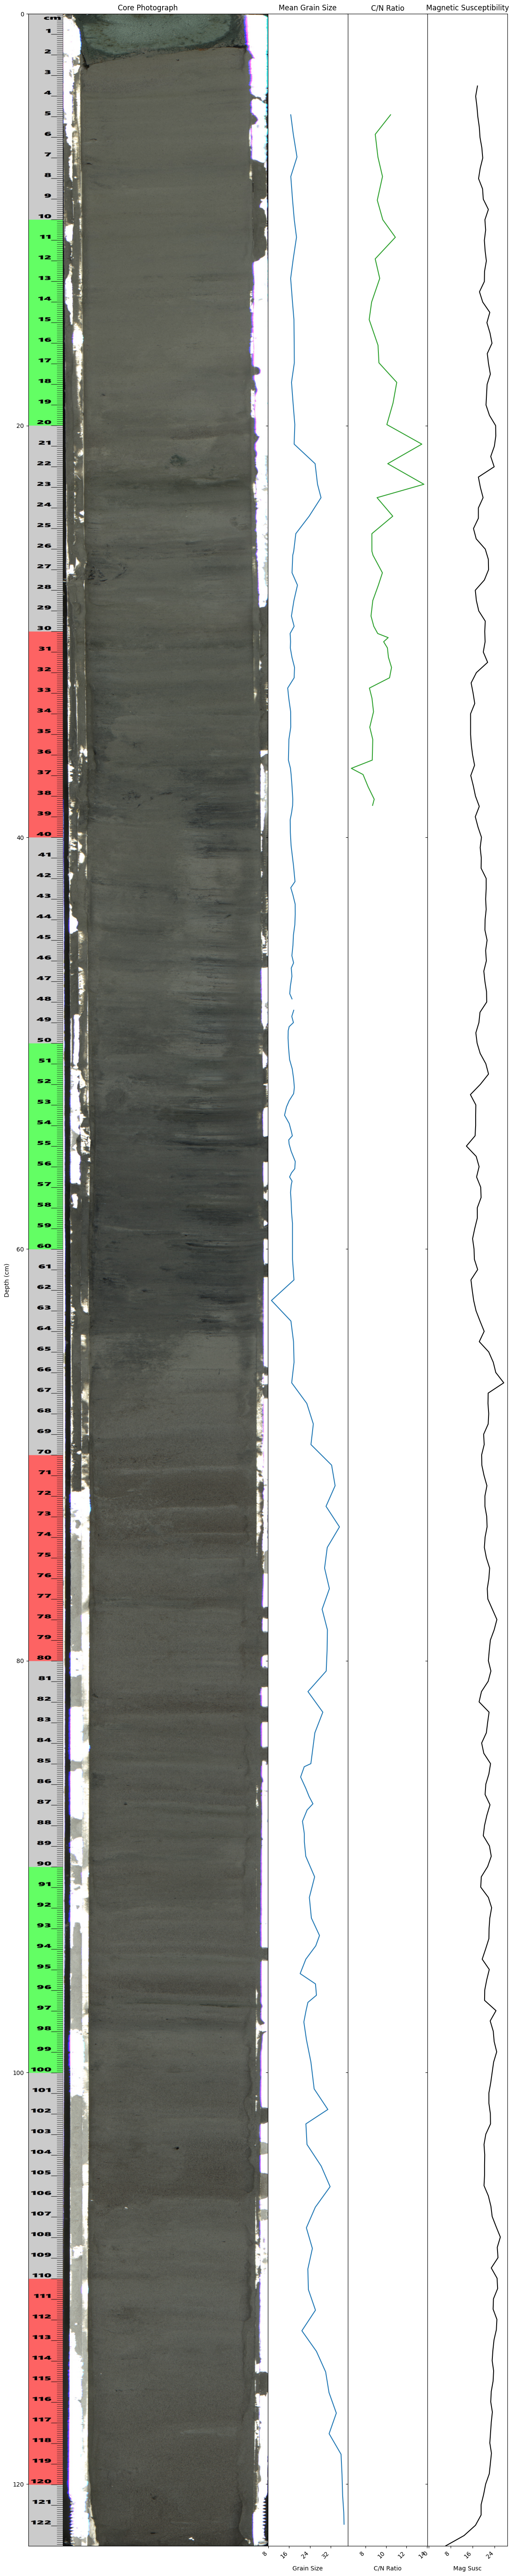

In [ ]:
#Plotting function
def plot_core(core_image_path, properties_df, lab_results_df):

    # -----------------------------
    # Load image
    # -----------------------------
    img = mpimg.imread(core_image_path)

    # -----------------------------
    # Data
    # -----------------------------
    p_df = properties_df

    depth_ms = p_df["Depth_cm"]
    ms = p_df["Magnetic_Susceptibility_x10_5_SI"]

    depth_lab = lab_results_df["Depth_Midpoint_cm"]
    grain_mean = lab_results_df["Grain_Size_Mean"]
    cn_ratio = lab_results_df["CN_Ratio"]

    # -----------------------------
    # Figure with custom width ratios
    # Image = 2, each proxy = 1
    # -----------------------------
    fig, axes = plt.subplots(
        1, 4,
        figsize=(12, 60),
        gridspec_kw={
            'width_ratios': [3, 1, 1, 1],
            'wspace': 0  # REMOVE gaps between plots
        },
        sharey=True
    )

    ax_img, ax_gs, ax_cn, ax_ms = axes

    # -----------------------------
    # Core image
    # -----------------------------
    ax_img.imshow(
        img,
        aspect='auto',
        extent=[0, 1, 0, 123],
        origin='lower'
    )

    ax_img.set_xticks([])
    ax_img.set_ylabel("Depth (cm)")
    ax_img.set_ylim(0, 123)
    ax_img.set_title("Core Photograph")

    # -----------------------------
    # Grain size
    # -----------------------------
    ax_gs.plot(grain_mean, depth_lab, color='tab:blue')
    ax_gs.invert_yaxis()
    ax_gs.set_xlabel("Grain Size", labelpad=10)
    ax_gs.set_title("Mean Grain Size")

    # -----------------------------
    # C/N ratio
    # -----------------------------
    ax_cn.plot(cn_ratio, depth_lab, color='tab:green')
    ax_cn.invert_yaxis()
    ax_cn.set_xlabel("C/N Ratio", labelpad=10)
    ax_cn.set_title("C/N Ratio")

    # -----------------------------
    # Magnetic susceptibility
    # -----------------------------
    ax_ms.plot(ms, depth_ms, color='black')
    ax_ms.invert_yaxis()
    ax_ms.set_xlabel("Mag Susc", labelpad=10)
    ax_ms.set_title("Magnetic Susceptibility")

    # -----------------------------
    # Reduce tick clutter + prevent overlap - NEEDS ADJUSTMENT
    # -----------------------------
    from matplotlib.ticker import MaxNLocator

    for ax in [ax_gs, ax_cn, ax_ms]:
        ax.xaxis.set_major_locator(MaxNLocator(4))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # -----------------------------
    # Final layout tuning
    # -----------------------------
    plt.subplots_adjust(wspace=0)
    plt.tight_layout()
    plt.show()


plot_core("Core Images/WAN1m17Mar26.jpg", physical_properties_17, lab_results_17)